In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pillow_lab_rotation import lds
from importlib import reload
inv = np.linalg.inv
plt.style.use('../JS.mplstyle')

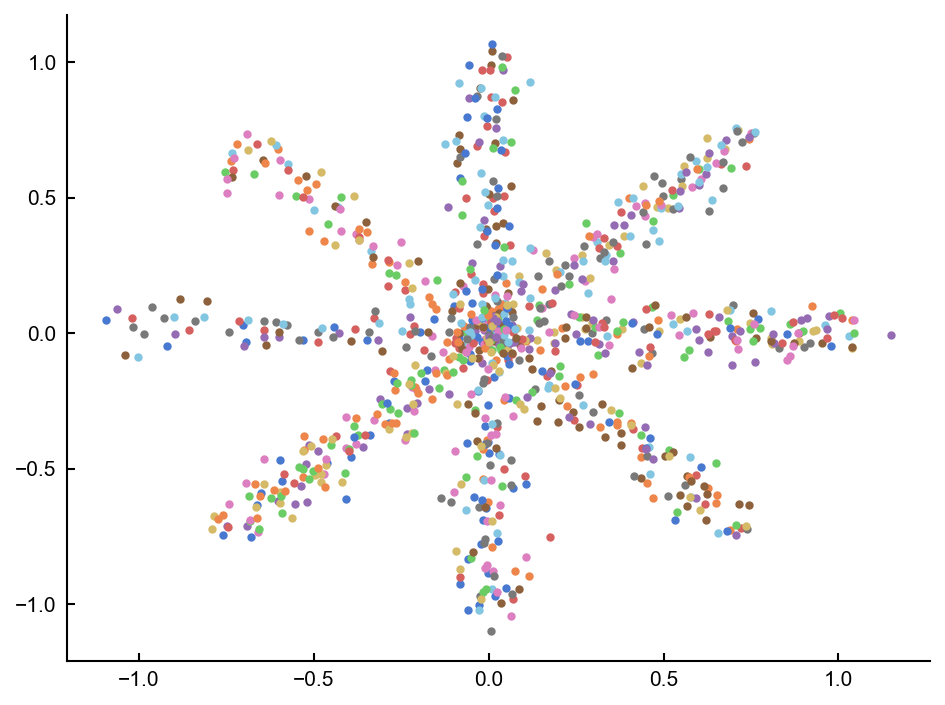

In [15]:
thetas = np.deg2rad(np.linspace(0, 360, 9))[:-1]
n_trials = 100
noise = 0.05
T = 10
r = np.linspace(0, 1, T)
X = np.zeros((n_trials, T, 2, 1))
for n in range(n_trials):
    theta = np.random.choice(thetas)
    # for i, theta in enumerate(thetas):
    x = r * np.cos(theta) + np.random.normal(0, noise, T)
    y = r * np.sin(theta) + np.random.normal(0, noise, T)
    X[n] = np.array([x, y]).T[..., None]
    plt.plot(x, y,  '.')

In [16]:
reload(lds)

<module 'pillow_lab_rotation.lds' from '/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/src/pillow_lab_rotation/lds.py'>

In [17]:
lds_model = lds.LinearDynamicalSystem(2, 2)

In [18]:
lds_model.fit(X)

In [19]:
from pillow_lab_rotation.plotting import plot_confidence_ellipse

/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/src/pillow_lab_rotation/plotting.py:55: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(contour_1[:,0], contour_1[:,1], 'b-', linewidth=0.5, c='k')
/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/src/pillow_lab_rotation/plotting.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(contour_2[:,0], contour_2[:,1], 'b-', linewidth=0.5, c='k')


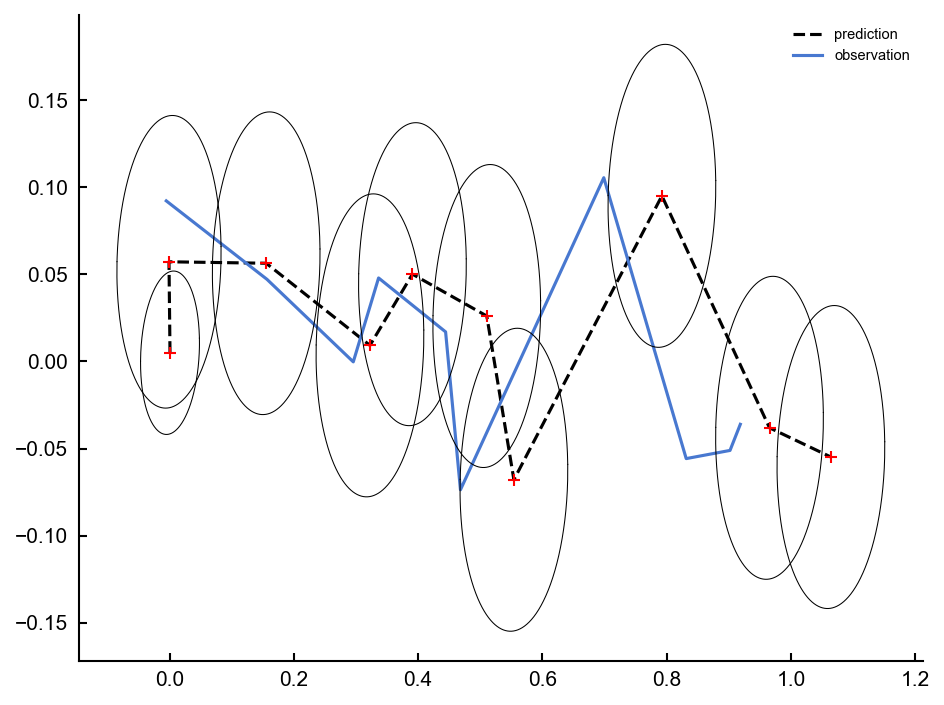

In [20]:
z_pred, pred_cvs, obs_mean, obs_cov, z_filt, post_covs, LL = lds_model.predict(X)
trial = 7

plt.plot(obs_mean[trial, :, 0, 0], obs_mean[trial, :, 1, 0], linestyle='--', label='prediction', c='k')
plt.plot(X[trial, :, 0, 0], X[trial, :, 1, 0], label='observation')
for t in range(T):
    plot_confidence_ellipse(obs_mean[trial, t, :, 0], obs_cov[trial, t])

plt.legend()

In [21]:
lds_model.M11

array([[1.63302694, 1.64455029],
       [1.64455029, 3.87283604]])

## Test LDS with inputs

In [22]:
# Ground truth parameters
xdim, ydim, udim = 2, 2, 1
n_trials = 200
T = 50

# Stable rotation dynamics (slow rotation)
theta_rot = np.deg2rad(10)
A_true = 0.95 * np.array([[np.cos(theta_rot), -np.sin(theta_rot)],
                           [np.sin(theta_rot),  np.cos(theta_rot)]])

# Input drives state in x-direction
B_true = np.array([[0.5], [0.0]])

# Direct observation
C_true = np.eye(2)

# No direct feedthrough
D_true = np.zeros((2, 1))

# Noise
Q_true = 0.01 * np.eye(2)
R_true = 0.1 * np.eye(2)
Q0_true = np.eye(2)
mu0_true = np.zeros((2, 1))

print("A_true:\n", A_true)
print("B_true:\n", B_true)
print("Eigenvalues of A:", np.linalg.eigvals(A_true))

A_true:
 [[ 0.93556737 -0.16496577]
 [ 0.16496577  0.93556737]]
B_true:
 [[0.5]
 [0. ]]
Eigenvalues of A: [0.93556737+0.16496577j 0.93556737-0.16496577j]


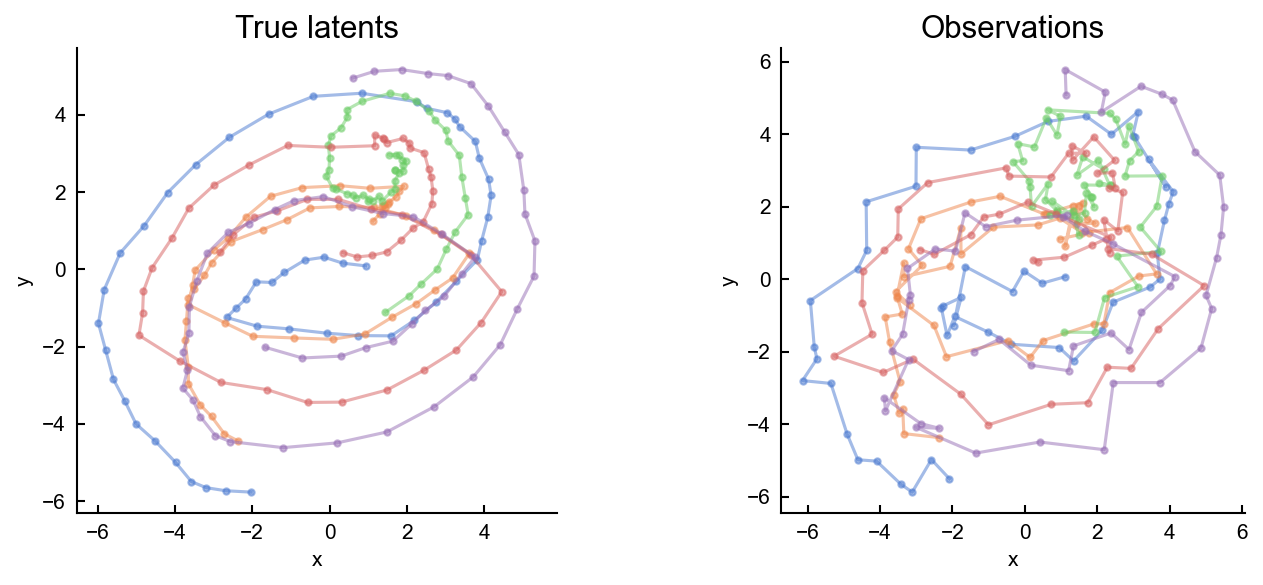

In [23]:
# Simulate data with inputs
rng = np.random.default_rng(42)

# Input signal: piecewise constant pulses (different per trial)
U = np.zeros((n_trials, T, udim, 1))
for n in range(n_trials):
    # Random pulse: input is +1 or -1 in blocks of ~10 timesteps
    for start in range(0, T, 10):
        U[n, start:start+10, 0, 0] = rng.choice([-1, 1])

# Simulate latents and observations
X_true = np.zeros((n_trials, T, xdim, 1))
Y = np.zeros((n_trials, T, ydim, 1))

for n in range(n_trials):
    x = rng.multivariate_normal(mu0_true.ravel(), Q0_true)[:, None]
    for t in range(T):
        if t == 0:
            x = x + B_true @ U[n, t, :, :]
        else:
            x = A_true @ x + B_true @ U[n, t, :, :]
            x += rng.multivariate_normal(np.zeros(xdim), Q_true)[:, None]
        X_true[n, t] = x
        Y[n, t] = C_true @ x + D_true @ U[n, t, :, :] + rng.multivariate_normal(np.zeros(ydim), R_true)[:, None]

# Plot a few example trials
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for trial in range(5):
    axes[0].plot(X_true[trial, :, 0, 0], X_true[trial, :, 1, 0], '.-', alpha=0.5)
    axes[1].plot(Y[trial, :, 0, 0], Y[trial, :, 1, 0], '.-', alpha=0.5)
axes[0].set_title('True latents')
axes[1].set_title('Observations')
for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')

In [24]:
# Fit model with inputs
reload(lds)
model = lds.LinearDynamicalSystem(xdim, ydim, udim)
model.fit(Y, U)

In [25]:
# Compare recovered parameters to ground truth
print("=== A ===")
print("True:\n", A_true)
print("Recovered:\n", model.A)

print("\n=== B ===")
print("True:\n", B_true)
print("Recovered:\n", model.B)

print("\n=== C ===")
print("True:\n", C_true)
print("Recovered:\n", model.C)

print("\n=== D ===")
print("True:\n", D_true)
print("Recovered:\n", model.D)

print("\n=== Q ===")
print("True:\n", Q_true)
print("Recovered:\n", model.Q)

print("\n=== R ===")
print("True:\n", R_true)
print("Recovered:\n", model.R)

=== A ===
True:
 [[ 0.93556737 -0.16496577]
 [ 0.16496577  0.93556737]]
Recovered:
 [[ 0.97435421  0.10099702]
 [-0.28371309  0.89690309]]

=== B ===
True:
 [[0.5]
 [0. ]]
Recovered:
 [[-0.31749663]
 [ 0.59233748]]

=== C ===
True:
 [[1. 0.]
 [0. 1.]]
Recovered:
 [[-0.67679639  0.48079241]
 [ 0.98594657  0.52938416]]

=== D ===
True:
 [[0.]
 [0.]]
Recovered:
 [[-0.00035634]
 [-0.01239639]]

=== Q ===
True:
 [[0.01 0.  ]
 [0.   0.01]]
Recovered:
 [[ 0.00763623 -0.00260918]
 [-0.00260918  0.02114844]]

=== R ===
True:
 [[0.1 0. ]
 [0.  0.1]]
Recovered:
 [[1.03830072e-01 9.72909442e-05]
 [9.72909442e-05 9.70301524e-02]]


Text(0.5, 0.98, 'Trial 21: True vs Smoothed Latents')

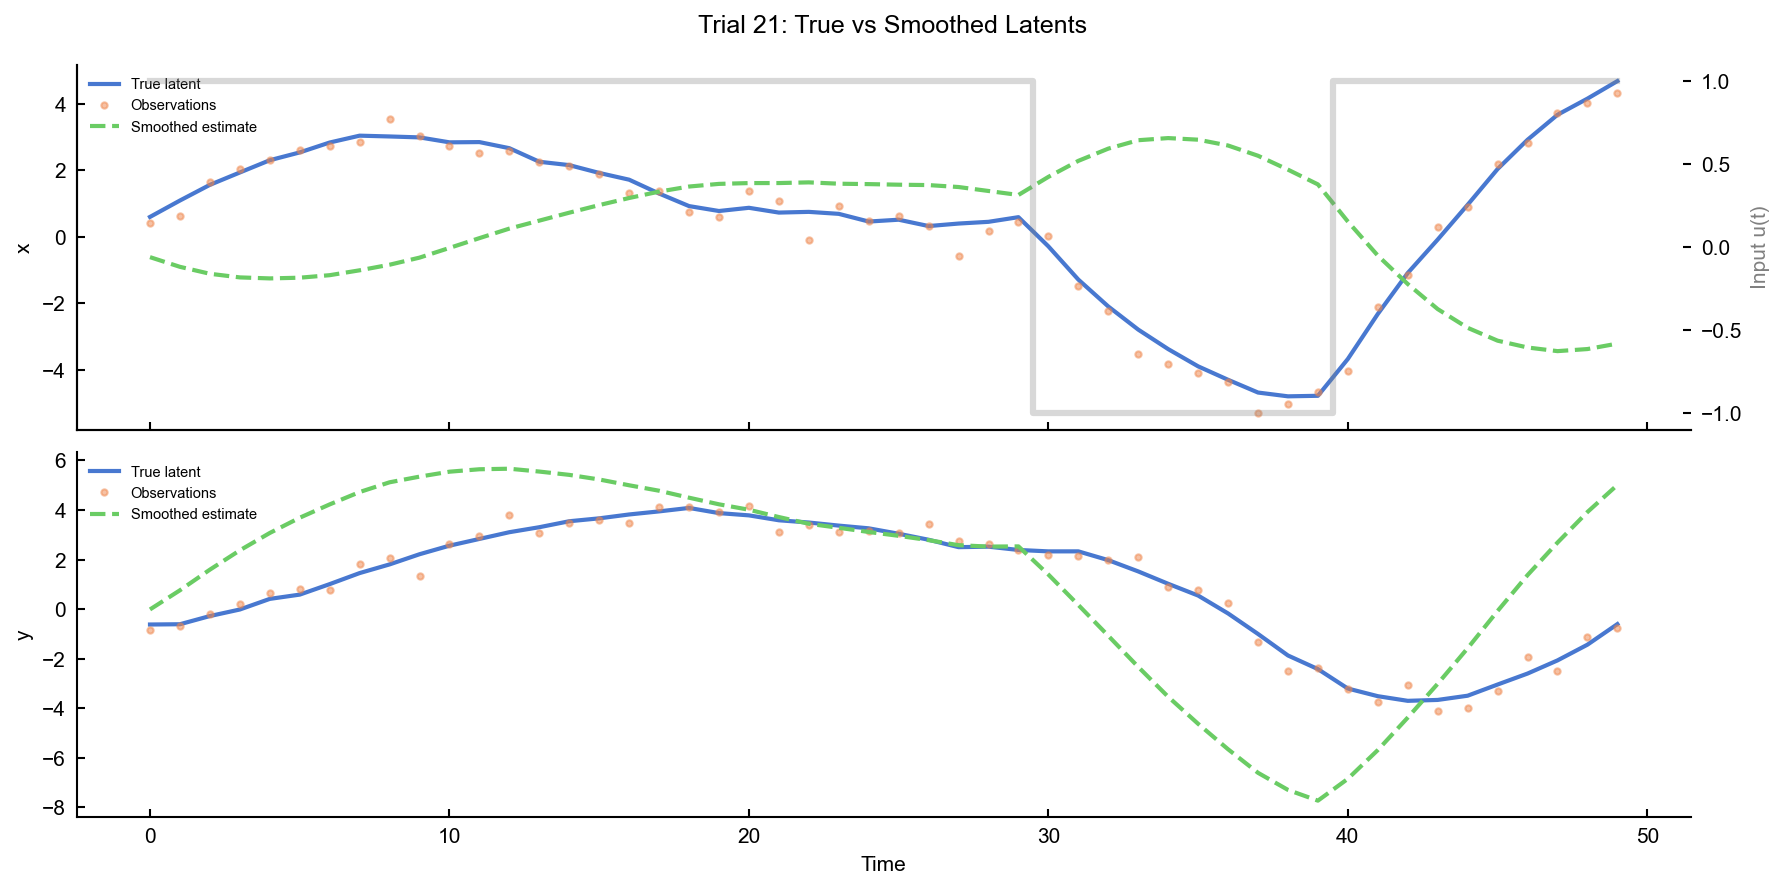

In [38]:
# Plot smoothed latents vs true latents for a single trial
trial = 21

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for dim, label in enumerate(['x', 'y']):
    axes[dim].plot(X_true[trial, :, dim, 0], label='True latent', linewidth=2)
    axes[dim].plot(Y[trial, :, dim, 0], '.', label='Observations', alpha=0.5)
    axes[dim].plot(model.m[trial, :, dim, 0], '--', label='Smoothed estimate', linewidth=2)
    axes[dim].set_ylabel(label)
    axes[dim].legend()

# Plot the input signal on a twin axis
ax_u = axes[0].twinx()
ax_u.step(range(T), U[trial, :, 0, 0], color='gray', alpha=0.3, linewidth=3, where='mid')
ax_u.set_ylabel('Input u(t)', color='gray')

axes[-1].set_xlabel('Time')
fig.suptitle(f'Trial {trial}: True vs Smoothed Latents')

In [27]:
# Check identifiability-invariant quantities
print("=== Eigenvalues of A (should match) ===")
print("True:     ", np.linalg.eigvals(A_true))
print("Recovered:", np.linalg.eigvals(model.A))

print("\n=== C @ B (impulse response, invariant) ===")
print("True:     ", (C_true @ B_true).ravel())
print("Recovered:", (model.C @ model.B).ravel())

print("\n=== C @ A^k @ B for k=0..4 (higher-order impulse response) ===")
for k in range(5):
    true_ir = C_true @ np.linalg.matrix_power(A_true, k) @ B_true
    rec_ir = model.C @ np.linalg.matrix_power(model.A, k) @ model.B
    print(f"  k={k}: true={true_ir.ravel()}, recovered={rec_ir.ravel()}")

print("\n=== D and R (directly identifiable, no transform) ===")
print("D true:", D_true.ravel(), " recovered:", model.D.ravel())
print("R true:\n", R_true)
print("R recovered:\n", model.R)

=== Eigenvalues of A (should match) ===
True:      [0.93556737+0.16496577j 0.93556737-0.16496577j]
Recovered: [0.93562865+0.16478625j 0.93562865-0.16478625j]

=== C @ B (impulse response, invariant) ===
True:      [0.5 0. ]
Recovered: [0.49967194 0.00053936]

=== C @ A^k @ B for k=0..4 (higher-order impulse response) ===
  k=0: true=[0.5 0. ], recovered=[0.49967194 0.00053936]
  k=1: true=[0.46778368 0.08248288], recovered=[0.46761996 0.08290829]
  k=2: true=[0.4240363  0.15433659], recovered=[0.42405561 0.15465594]
  k=3: true=[0.37125427 0.21434375], recovered=[0.37146421 0.21457172]
  k=4: true=[0.31197399 0.26177726], recovered=[0.31237139 0.26193334]

=== D and R (directly identifiable, no transform) ===
D true: [0. 0.]  recovered: [-0.00035634 -0.01239639]
R true:
 [[0.1 0. ]
 [0.  0.1]]
R recovered:
 [[1.03830072e-01 9.72909442e-05]
 [9.72909442e-05 9.70301524e-02]]
